# CSCIE89 : CNN - Multi Class Classification : Five Flower Categories

We will train a small convolutional neural network **from scratch** on real color photographs. No pretrained weights are used, that will be discussed next week in the class. 

We will download images, inspect labels, create separate training/validation/test sets, resize images, build a classification CNN, train it, and evaluate predictions. Unlike the previous 8×8 digits example, these images have three color channels and varied backgrounds, so the task is harder.

The first run needs internet access and disk space for the downloaded images. Or you can download ahead of time.

Downloads are reused on subsequent runs. Training time depends on your computer; a GPU will help. 

The default is 15 epochs and 64×64 images to keep this manageable.  

We will do 50 epochs and also make a point around why its important to keep an eye on the Validataion and Test loss.

## 1. Install packages and import tools

If the imports fail, uncomment the installation line, run it once, then restart the kernel. TensorFlow is not required, even for the Flower Photos dataset.

In [1]:
# %pip install torch torchvision scikit-learn matplotlib pillow

from pathlib import Path
import copy
import json
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    ConfusionMatrixDisplay,
)

# Seeds make the split and initial weights repeatable, but do not guarantee
# identical floating-point results across all devices or PyTorch versions.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)  # Avoid excessive CPU thread overhead on this small model.
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
IMAGE_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.001
print('PyTorch:', torch.__version__, '| Device:', device)

PyTorch: 2.14.0+cu130 | Device: cpu


## 2. Download Flower Photos and read the labels

The [Flower Photos dataset](https://www.tensorflow.org/tutorials/images/classification) has 3,670 photographs in five folders: daisy, dandelion, roses, sunflowers, and tulips. The archive is approximately 220 MB. 

`ImageFolder` daisy, roses etc -assigns labels from alphabetically sorted folder names. We read that mapping instead of guessing the numbers. This dataset has no official test split, so we will make a reproducible stratified 70%/15%/15% split.

In [2]:
# GOOGLE DRIVE + LOCAL COLAB SETUP

from google.colab import drive  # Colab helper that connects your Google Drive to this session.
from pathlib import Path  # Path objects make building file paths with "/" easy and readable.
import shutil  # Standard-library tools for copying files.
from torchvision.datasets.utils import extract_archive  # Unpacks a .tgz archive (download_and_extract_archive is imported in Section 1).

drive.mount('/content/drive')  # Mounts Google Drive at /content/drive (asks for permission the first time).

# Permanent location in Google Drive
PROJECT_DIR = Path('/content/drive/MyDrive/AI/Flowers_CNN')  # Project folder in your Drive; survives after the Colab session ends.
DRIVE_DATA_DIR = PROJECT_DIR / 'data'  # Subfolder in Drive that holds the permanent copy of the dataset.
DRIVE_DATA_DIR.mkdir(parents=True, exist_ok=True)  # Creates the folder (and any missing parents); no error if it already exists.

# IMPORTANT: DATA_DIR is the fast temporary Colab drive
DATA_DIR = Path('/content/data')  # Local Colab disk: much faster to read than Drive, but wiped when the session ends.
DATA_DIR.mkdir(parents=True, exist_ok=True)  # Creates the local data folder; no error if it already exists.

FLOWERS_URL = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'  # ~220 MB archive of 3,670 photos.
flower_root = DATA_DIR / 'flower_photos'  # Where the images live during this session (used for training).
local_archive = DATA_DIR / 'flower_photos.tgz'  # The download step keeps the archive here, named after the URL's file name.
# The permanent copy in Drive is the single archive file, not 3,670 separate images:
# Drive is slow with many small files, but copies one large file quickly.
drive_archive = DRIVE_DATA_DIR / 'flower_photos.tgz'

# If flowers are not already in Colab
if not flower_root.exists():  # True at the start of every new Colab session, since local disk starts empty.

    # Unpack the archive saved in Google Drive, if there is one
    if drive_archive.exists():  # An archive was saved to Drive in an earlier session...
        extract_archive(str(drive_archive), str(DATA_DIR))  # ...so unpack it onto the fast local disk (creates flower_photos/).

    # Otherwise download and unpack them into Colab
    else:  # First time ever: no archive in Drive yet.
        download_and_extract_archive(FLOWERS_URL, download_root=str(DATA_DIR))  # Saves the .tgz in DATA_DIR and unpacks it there.

# Save a permanent copy of the archive to Google Drive if one does not exist
if not drive_archive.exists() and local_archive.exists():  # Only after a fresh download (local archive present, none in Drive).
    partial = drive_archive.with_name(drive_archive.name + '.partial')  # Temporary name used while copying.
    shutil.copy2(local_archive, partial)  # Copy under the temporary name first...
    partial.rename(drive_archive)  # ...then rename, so an interrupted copy is never mistaken for a finished one.

# ______________________________________________________________________________________________________
catalog = datasets.ImageFolder(flower_root)  # Scans the class subfolders; each folder name becomes a class.
# The full dataset has 3,670 photos. Fewer means an incomplete copy, which would silently change the split.
assert len(catalog) == 3670, f'Expected 3,670 images, found {len(catalog)}: delete {flower_root} and re-run this cell.'
class_names = catalog.classes  # Folder names sorted alphabetically: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'].

# Each record is (path_to_image, integer_class_label).
records = [(Path(path), label) for path, label in catalog.samples]  # catalog.samples lists every image with its label.

labels = [label for _, label in records]  # Just the labels, needed to stratify the split below.

train_records, remaining = train_test_split(  # First split: 70% training, 30% set aside.
    records,  # All 3,670 (path, label) pairs.
    test_size=0.30,  # 30% goes to `remaining` (later split into validation and test).
    random_state=SEED,  # Fixed seed so the split is identical on every run.
    stratify=labels  # Keeps the same class proportions in both parts.
)

val_records, test_records = train_test_split(  # Second split: the 30% becomes 15% validation + 15% test.
    remaining,  # The 30% set aside above.
    test_size=0.50,  # Half of it (15% of all images) becomes the test set.
    random_state=SEED,  # Same fixed seed for reproducibility.
    stratify=[label for _, label in remaining]  # Keeps class proportions equal in validation and test.
)

print('Folder-to-label mapping:', catalog.class_to_idx)  # Shows which integer label each flower folder received.

Folder-to-label mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


## 3. Check the split and look at real images

Training images teach the weights. Validation images select the best epoch. Test images are reserved for final evaluation, after those decisions. Never adjust settings based on test results; use validation results for experiments.

Train: 2569 images | {'daisy': 443, 'dandelion': 629, 'roses': 449, 'sunflowers': 489, 'tulips': 559}
Validation: 550 images | {'daisy': 95, 'dandelion': 134, 'roses': 96, 'sunflowers': 105, 'tulips': 120}
Test: 551 images | {'daisy': 95, 'dandelion': 135, 'roses': 96, 'sunflowers': 105, 'tulips': 120}


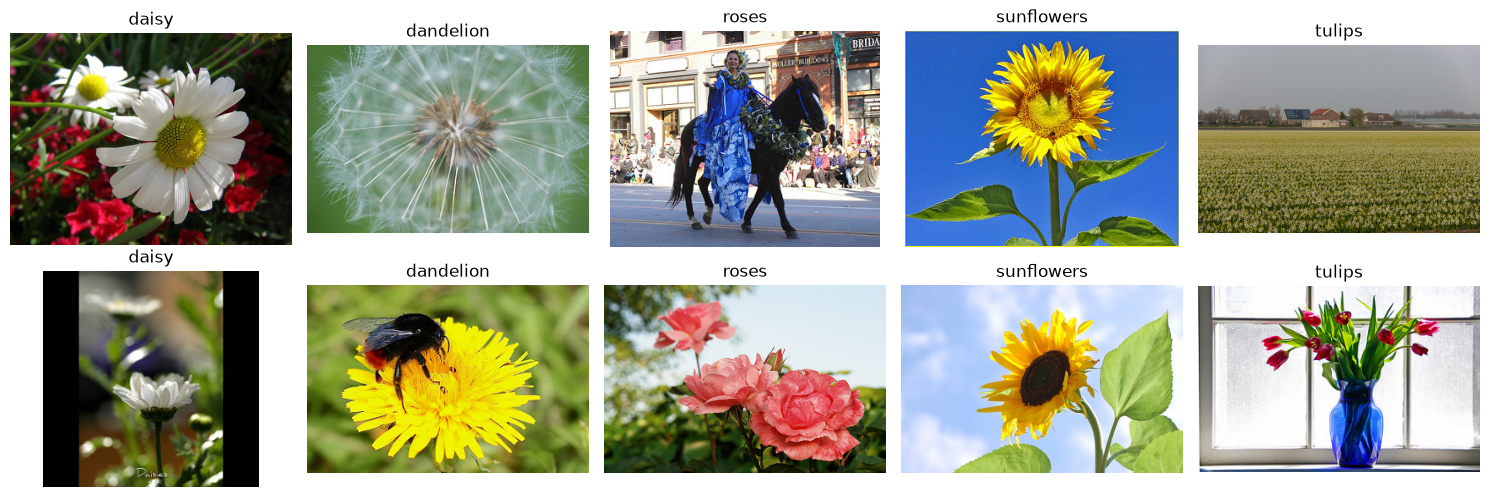

In [3]:
# A path must appear in only one split: this checks for accidental overlap.
train_paths = {path for path, _ in train_records}
val_paths = {path for path, _ in val_records}
test_paths = {path for path, _ in test_records}
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)
for name, records in [('Train', train_records), ('Validation', val_records), ('Test', test_records)]:
    counts = np.bincount([label for _, label in records], minlength=len(class_names))
    print(f'{name}: {len(records)} images | {dict(zip(class_names, counts.tolist()))}')

# Show two training examples per class, before resizing.
fig, axes = plt.subplots(2, len(class_names), figsize=(3 * len(class_names), 5), squeeze=False)
for label, name in enumerate(class_names):
    examples = [path for path, target in train_records if target == label][:2]
    for row, path in enumerate(examples):
        with Image.open(path) as picture:
            axes[row, label].imshow(picture.convert('RGB'))
        axes[row, label].set_title(name)
        axes[row, label].axis('off')
plt.tight_layout()
plt.show()

## 4. Convert images into tensors and batches

Photos vary in size. We resize each one to 64×64 pixels (this simple resize can distort aspect ratios). `ToTensor` changes pixels from integers in 0–255 to floats in 0–1 and rearranges the dimensions to **channels, height, width**. RGB means three channels: red, green, blue.

A small custom `Dataset` loads one image when requested instead of keeping every full-resolution image in memory. `DataLoader` collects these images into batches. Only training batches are shuffled. This baseline uses the same deterministic preprocessing for all splits; augmentation can be a later experiment.

In [4]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

class PhotoDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        path, label = self.records[index]
        with Image.open(path) as picture:
            # Convert even grayscale/RGBA files to three-channel RGB.
            image = self.transform(picture.convert('RGB'))
        return image, label

train_dataset = PhotoDataset(train_records, image_transform)
val_dataset = PhotoDataset(val_records, image_transform)
test_dataset = PhotoDataset(test_records, image_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                          shuffle=True,
                          generator=torch.Generator().manual_seed(SEED), 
                          num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, targets = next(iter(train_loader))

print('Images:', images.shape, '| Labels:', targets.shape, targets.dtype)
assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)

Images: torch.Size([64, 3, 64, 64]) | Labels: torch.Size([64]) torch.int64


## 5. Build a vanilla CNN

A convolution learns small filters that detect patterns such as edges and textures. ReLU replaces negative values with zero and enables nonlinear relationships. Max pooling halves the spatial dimensions, retaining strong responses. Flatten turns the final feature maps into a vector; linear layers turn that vector into class scores, called logits.

For one image the shapes are: `3×64×64 → 16×32×32 → 32×16×16 → 64×8×8 → 4096 → 64 → number of classes`. Each arrow through the feature extractor includes convolution, ReLU, and pooling.

We use cross-entropy for both lessons. Cats versus dogs therefore has **two output logits**, while flowers has five. Cross-entropy expects integer targets, and internally handles the softmax-related calculation; do not add softmax before this loss.

In [5]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMAGE_SIZE // 8) ** 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = BasicCNN(len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    assert model(images.to(device)).shape == (len(images), len(class_names))

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)
Trainable parameters: 286117


## 6. Define evaluation, then train

One epoch is a complete pass through training data. Each batch follows five steps: clear gradients, predict, calculate loss, backpropagate, update weights. Evaluation uses `model.eval()` and `torch.no_grad()` because it must not update weights or build a gradient graph.

We multiply each batch's mean loss by its actual size before averaging across examples, so a smaller final batch has the correct weight. Training metrics below are measured while weights change; validation metrics use the fixed weights at the end of each epoch.

We keep the weights with the lowest **validation loss**, not the highest test accuracy. The test loader is not used during training.

In [6]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss_sum += criterion(logits, labels).item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            count += len(labels)
    return loss_sum / count, correct / count

history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
best_val_loss = float('inf')
best_state = None
start = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, correct, count = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()             # Clear gradients from the last batch.
        logits = model(inputs)            # Forward pass.
        loss = criterion(logits, labels)  # Compare scores with true labels.
        loss.backward()                   # Calculate weight gradients.
        optimizer.step()                  # Update weights using Adam.
        loss_sum += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        count += len(labels)
    train_loss, train_accuracy = loss_sum / count, correct / count
    val_loss, val_accuracy = evaluate(model, val_loader)
    for key, value in [('train_loss', train_loss), ('val_loss', val_loss),
                       ('train_accuracy', train_accuracy), ('val_accuracy', val_accuracy)]:
        history[key].append(value)
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch
        # A copy is necessary: a plain reference would keep changing during training.
        best_state = copy.deepcopy(model.state_dict())
    print(f'Epoch {epoch:02d}/{EPOCHS} | train loss {train_loss:.3f}, acc {train_accuracy:.1%}'
          f' | val loss {val_loss:.3f}, acc {val_accuracy:.1%}', flush=True)

model.load_state_dict(best_state)
print(f'Restored epoch {best_epoch}, selected using validation loss.')
print(f'Training time: {(time.perf_counter() - start) / 60:.1f} minutes')

Epoch 01/15 | train loss 1.439, acc 35.8% | val loss 1.347, acc 42.0%


Epoch 02/15 | train loss 1.178, acc 49.8% | val loss 1.127, acc 55.6%


Epoch 03/15 | train loss 1.073, acc 57.4% | val loss 1.047, acc 57.5%


Epoch 04/15 | train loss 1.014, acc 59.4% | val loss 1.021, acc 59.1%


Epoch 05/15 | train loss 0.963, acc 61.1% | val loss 1.027, acc 58.2%


...

Epoch 12/15 | train loss 0.739, acc 71.3% | val loss 0.963, acc 64.0%


Epoch 13/15 | train loss 0.710, acc 72.3% | val loss 0.929, acc 65.1%


Epoch 14/15 | train loss 0.683, acc 73.2% | val loss 0.926, acc 66.2%


Epoch 15/15 | train loss 0.658, acc 74.9% | val loss 1.165, acc 59.3%


Restored epoch 14, selected using validation loss.
Training time: 1.9 minutes


## 7. Plot learning curves

Lower loss and higher accuracy generally indicate learning. Training improvement accompanied by worsening validation loss suggests overfitting: the model fits training details that do not generalize. The dashed line marks the selected epoch.

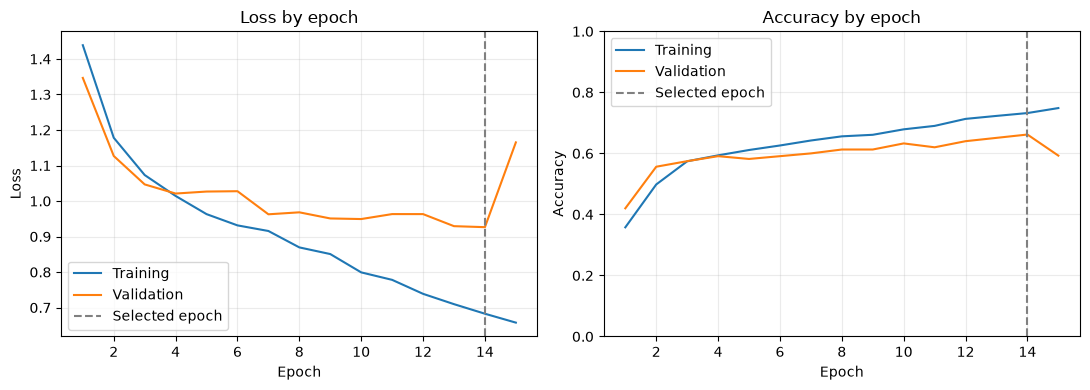

In [7]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['loss', 'accuracy']):
    ax.plot(epochs, history['train_' + metric], label='Training')
    ax.plot(epochs, history['val_' + metric], label='Validation')
    ax.axvline(best_epoch, color='gray', linestyle='--', label='Selected epoch')
    ax.set(xlabel='Epoch', ylabel=metric.capitalize(), title=metric.capitalize() + ' by epoch')
    ax.legend()
    ax.grid(alpha=0.25)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Evaluate the selected model on the test set

**Accuracy** is the fraction correct. **Precision** asks how often predictions of a class are right; **recall** asks how many real members of that class we found. **F1** balances precision and recall. **Support** is the number of examples in a class. Macro averages give each class equal weight; weighted averages give more weight to larger classes.

Balanced accuracy averages recall across classes, which helps when class counts differ (there are more dogs than cats in Oxford Pets). We also compare with a trivial model that always predicts the most common *training* class. Confusion-matrix rows are true classes and columns are predictions.

Test loss: 0.8880
Test accuracy: 66.42%
Balanced accuracy: 65.13%
Always predict dandelion baseline: 24.50%
              precision    recall  f1-score   support

       daisy       0.64      0.64      0.64        95
   dandelion       0.67      0.79      0.72       135
       roses       0.63      0.35      0.45        96
  sunflowers       0.77      0.80      0.79       105
      tulips       0.60      0.68      0.64       120

    accuracy                           0.66       551
   macro avg       0.66      0.65      0.65       551
weighted avg       0.66      0.66      0.65       551



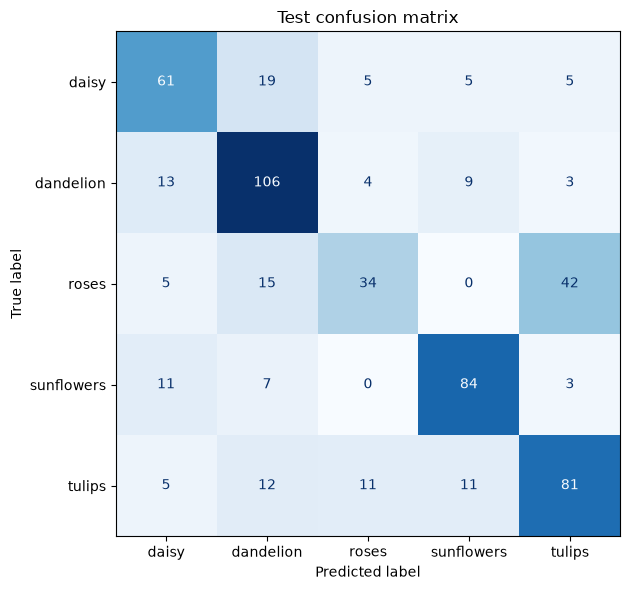

In [8]:
model.eval()
true_labels, predicted_labels, probabilities = [], [], []
test_loss_sum = 0.0
with torch.no_grad():
    for inputs, labels in test_loader:
        logits = model(inputs.to(device))
        test_loss_sum += criterion(logits, labels.to(device)).item() * len(labels)
        # Softmax is useful here to display scores as probabilities.
        # These are model scores, not guarantees or calibrated confidence estimates.
        probabilities.extend(logits.softmax(1).cpu().numpy())
        predicted_labels.extend(logits.argmax(1).cpu().numpy())
        true_labels.extend(labels.numpy())
true_labels = np.asarray(true_labels)
predicted_labels = np.asarray(predicted_labels)
probabilities = np.asarray(probabilities)
test_loss = test_loss_sum / len(true_labels)
test_accuracy = accuracy_score(true_labels, predicted_labels)
balanced_accuracy = balanced_accuracy_score(true_labels, predicted_labels)
majority_class = np.bincount([label for _, label in train_records]).argmax()
baseline_accuracy = np.mean(true_labels == majority_class)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.2%}')
print(f'Balanced accuracy: {balanced_accuracy:.2%}')
print(f'Always predict {class_names[majority_class]} baseline: {baseline_accuracy:.2%}')
print(classification_report(true_labels, predicted_labels,
      labels=list(range(len(class_names))), target_names=class_names, zero_division=0))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(true_labels, predicted_labels,
    labels=list(range(len(class_names))), display_labels=class_names,
    cmap='Blues', colorbar=False, ax=ax)
ax.set_title('Test confusion matrix')
plt.tight_layout()
plt.show()

## 9. Inspect predictions and mistakes

Visual inspection helps reveal ambiguous photos and recurring errors. The first grid is a reproducible random test sample; the second contains only mistakes. Correct titles are green and incorrect titles are red.

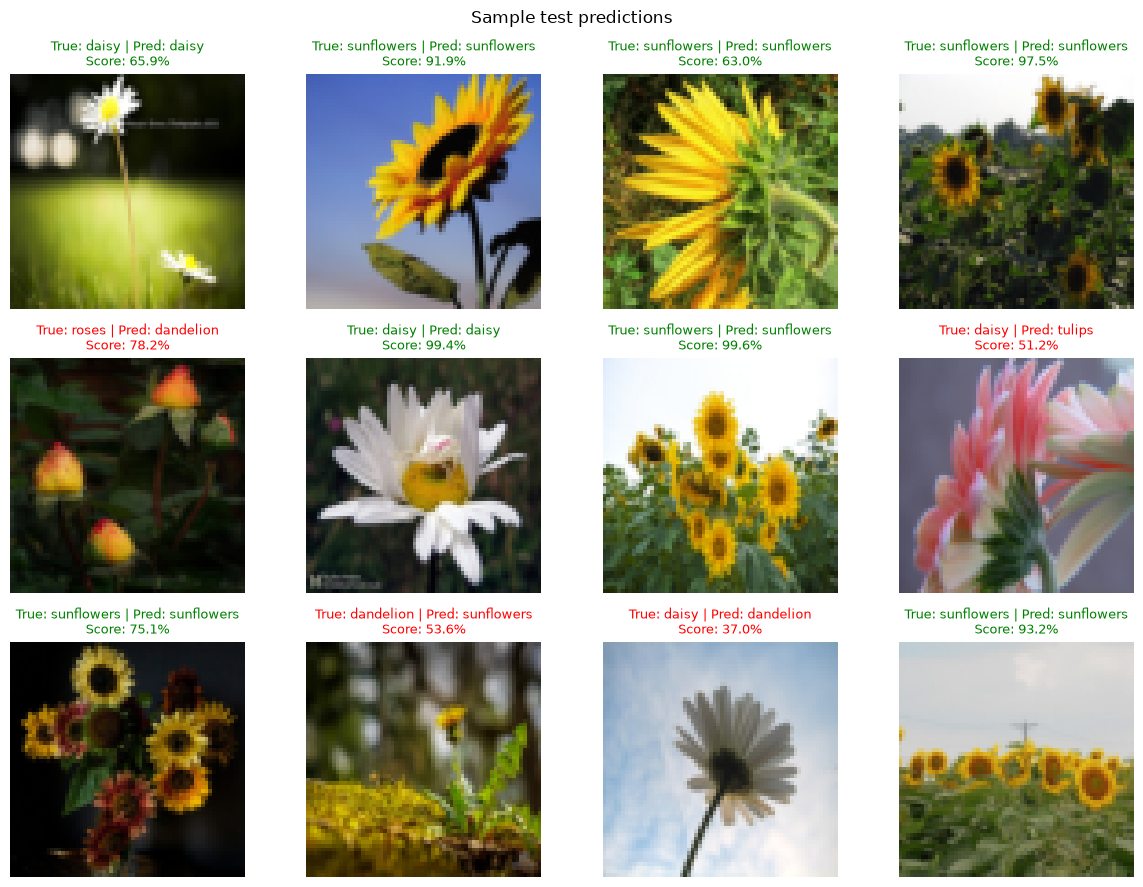

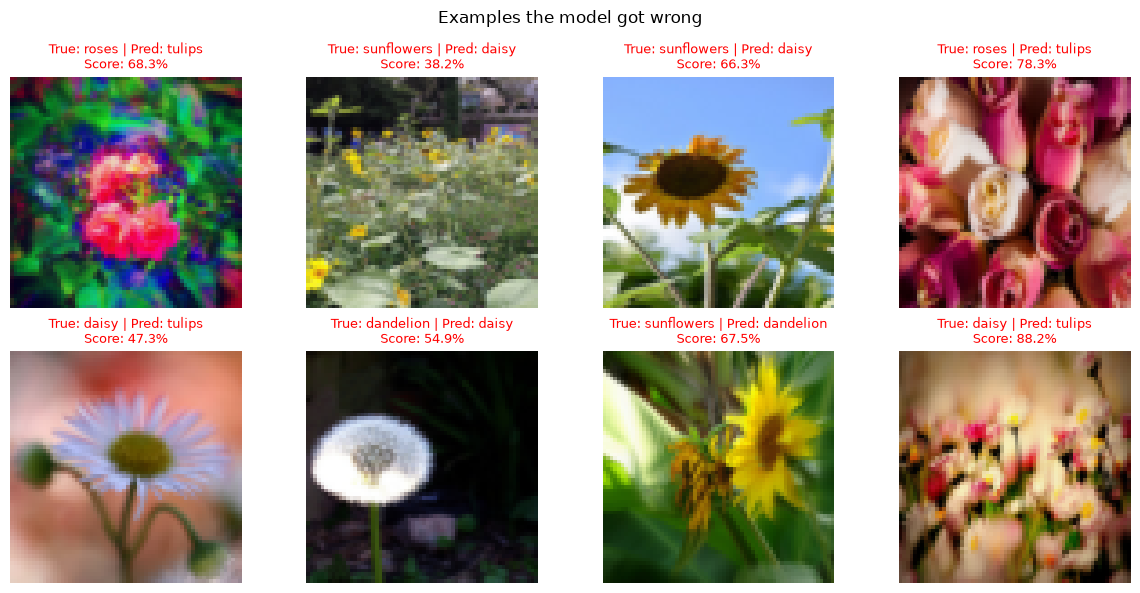

In [9]:
def show_predictions(indices, title):
    if len(indices) == 0:
        print('No mistakes in this test run.')
        return
    fig, axes = plt.subplots((len(indices) + 3) // 4, 4,
                             figsize=(12, 3 * ((len(indices) + 3) // 4)), squeeze=False)
    for ax in axes.flat:
        ax.axis('off')
    for ax, index in zip(axes.flat, indices):
        image, actual = test_dataset[int(index)]
        predicted = predicted_labels[index]
        # Plotting needs H,W,C, whereas PyTorch stores C,H,W.
        ax.imshow(image.permute(1, 2, 0))
        ax.set_title(f'True: {class_names[actual]} | Pred: {class_names[predicted]}\n'
                     f'Score: {probabilities[index, predicted]:.1%}',
                     color='green' if actual == predicted else 'red', fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(SEED)
show_predictions(rng.choice(len(test_dataset), size=12, replace=False), 'Sample test predictions')
errors = np.flatnonzero(true_labels != predicted_labels)
show_predictions(errors[:8], 'Examples the model got wrong')

## 10. Save, reload, and predict one image

We save the weights together with class names and image size so the label mapping is not lost. Reconstruct the same model architecture before loading weights. The example below checks that reloaded weights give the same scores and demonstrates prediction for a single image.

In [10]:
OUTPUT_DIR = Path('outputs') / 'flowers'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model_path = OUTPUT_DIR / 'basic_cnn.pth'
torch.save({
    'state_dict': {key: value.cpu() for key, value in model.state_dict().items()},
    'class_names': class_names, 'image_size': IMAGE_SIZE, 'best_epoch': best_epoch,
}, model_path)
# Store metrics separately in a human-readable file.
metrics = {'test_loss': test_loss, 'test_accuracy': test_accuracy,
           'balanced_accuracy': balanced_accuracy, 'majority_baseline_accuracy': float(baseline_accuracy),
           'best_epoch': best_epoch, 'history': history}
(OUTPUT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))

checkpoint = torch.load(model_path, map_location='cpu', weights_only=True)
assert checkpoint['image_size'] == IMAGE_SIZE
reloaded = BasicCNN(len(checkpoint['class_names'])).to(device)
reloaded.load_state_dict(checkpoint['state_dict'])
reloaded.eval()
one_image, actual = test_dataset[0]
with torch.no_grad():
    batch = one_image.unsqueeze(0).to(device)  # Add batch dimension: (1,3,64,64).
    torch.testing.assert_close(model(batch), reloaded(batch))
    predicted = reloaded(batch).argmax(1).item()
print('Reload verified. Example:', checkpoint['class_names'][predicted],
      '| Actual:', class_names[actual])
print('Saved to:', model_path.resolve())

def predict_image(path):
    with Image.open(path) as image:
        batch = image_transform(image.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        scores = reloaded(batch).softmax(1)[0].cpu()
    index = scores.argmax().item()
    return checkpoint['class_names'][index], scores[index].item()

# Replace this with your own photo path to try another image.
print('Single-image prediction:', predict_image(test_records[0][0]))

Reload verified. Example: roses | Actual: roses
Saved to: /home/user/e89_Hussein_Jawad_HW04/outputs/flowers/basic_cnn.pth
Single-image prediction: ('roses', 0.8002821803092957)


## 11. Problem 2: A deeper CNN and hyperparameter experiments

**Task:** add 2 more convolutional blocks and one more linear layer with ReLU, then experiment with activation functions, kernel sizes, and pooling types to try to beat the baseline above, without overfitting. No data augmentation.

**How the experiments are run (same rules as Sections 6–8):**
- Every experiment uses the same data split, the same 15 epochs, and the same training loop from Section 6, wrapped in a function so it can be reused.
- Each run is reseeded so that all models start from the same random state and see batches in the same order. That way, differences come from the architecture or hyperparameter, not from luck.
- As in Section 6, each run keeps the weights from the epoch with the lowest **validation loss**. This guards against overfitting: if the model starts memorizing the training set, later epochs are simply not selected.
- Experiments are compared on **validation** results only. The test set is used **once**, at the very end, for the single chosen model.

**Experiments** (each one changes one thing at a time from experiment A, unless noted):

| Exp | Change |
|---|---|
| A | **Deeper network**: 5 conv blocks (2 new: 128 and 256 filters) + 1 extra `Linear` + `ReLU` layer |
| B | A + kernel size 5 instead of 3 |
| C | A + average pooling instead of max pooling |
| D | A + LeakyReLU instead of ReLU |
| E | A + BatchNorm after each conv + Dropout 0.3 in the classifier (regularization against overfitting) |
| F | E + LeakyReLU (combine the two best changes) |
| G | F + learning rate 0.0005 instead of 0.001 (to steady the noisy validation loss seen in E/F) |


In [11]:
# Save the baseline (Sections 5-8) results before `model` is replaced by the new experiments.
baseline_results = {
    'best_epoch': best_epoch,
    'val_loss': history['val_loss'][best_epoch - 1],
    'val_accuracy': history['val_accuracy'][best_epoch - 1],
    'train_accuracy': history['train_accuracy'][best_epoch - 1],
    'params': sum(p.numel() for p in model.parameters()),
}
baseline_history = history
baseline_test_accuracy, baseline_balanced_accuracy = test_accuracy, balanced_accuracy
print(f"Baseline: val loss {baseline_results['val_loss']:.3f}, val acc {baseline_results['val_accuracy']:.1%}, "
      f"test acc {baseline_test_accuracy:.1%}")

Baseline: val loss 0.926, val acc 66.2%, test acc 66.4%


### 11.1 The deeper CNN

Same structure as `BasicCNN` (a `features` block followed by a `classifier` block), but with **5** conv blocks instead of 3, and **3** linear layers instead of 2. The constructor arguments let each experiment swap in a different kernel size, activation, pooling type, or add BatchNorm/Dropout, without rewriting the class.

For one image the shapes are: `3×64×64 → 16×32×32 → 32×16×16 → 64×8×8 → 128×4×4 → 256×2×2 → 1024 → 128 → 64 → number of classes`. The last two arrows through the feature extractor (128 and 256 filters) are the 2 new conv blocks; `1024 → 128 → 64` adds the extra linear + activation layer.

In [12]:
class DeeperCNN(nn.Module):
    def __init__(self, num_classes, kernel_size=3, activation=nn.ReLU, pool=nn.MaxPool2d,
                 batch_norm=False, dropout=0.0):
        super().__init__()
        layers = []
        channels = [3, 16, 32, 64, 128, 256]  # 128 and 256 are the 2 new conv blocks.
        for c_in, c_out in zip(channels[:-1], channels[1:]):
            # padding = kernel_size // 2 keeps height and width unchanged for both 3x3 and 5x5 kernels.
            layers.append(nn.Conv2d(c_in, c_out, kernel_size=kernel_size, padding=kernel_size // 2))
            if batch_norm:
                layers.append(nn.BatchNorm2d(c_out))
            layers += [activation(), pool(2)]  # Each pool halves height and width: 64 -> 2 after 5 blocks.
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256 * (IMAGE_SIZE // 32) ** 2, 128),
            activation(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),  # The extra linear layer + activation.
            activation(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

deeper = DeeperCNN(len(class_names)).to(device)
print(deeper)
print('Trainable parameters:', sum(p.numel() for p in deeper.parameters()))
with torch.no_grad():
    assert deeper(images.to(device)).shape == (len(images), len(class_names))

DeeperCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1)

### 11.2 Run the experiments

`train_model` is the Section 6 training loop, unchanged, wrapped in a function. It returns the history and restores the weights from the epoch with the lowest validation loss.

In [13]:
def train_model(model, learning_rate=LEARNING_RATE):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
    best_val_loss, best_state, best_epoch = float('inf'), None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            count += len(labels)
        val_loss, val_accuracy = evaluate(model, val_loader)
        for key, value in [('train_loss', loss_sum / count), ('val_loss', val_loss),
                           ('train_accuracy', correct / count), ('val_accuracy', val_accuracy)]:
            history[key].append(value)
        if val_loss < best_val_loss:
            best_val_loss, best_epoch = val_loss, epoch
            best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return history, best_epoch

experiments = {
    'A: 5 conv blocks + extra linear': dict(),
    'B: A + kernel size 5': dict(kernel_size=5),
    'C: A + average pooling': dict(pool=nn.AvgPool2d),
    'D: A + LeakyReLU': dict(activation=nn.LeakyReLU),
    'E: A + BatchNorm + Dropout 0.3': dict(batch_norm=True, dropout=0.3),
    'F: E + LeakyReLU': dict(batch_norm=True, dropout=0.3, activation=nn.LeakyReLU),
    'G: F + learning rate 0.0005': dict(batch_norm=True, dropout=0.3, activation=nn.LeakyReLU,
                                        learning_rate=0.0005),
}

results = {'Baseline (3 conv blocks)': baseline_results}
histories = {'Baseline (3 conv blocks)': baseline_history}
trained_models = {}
start = time.perf_counter()
for name, settings in experiments.items():
    settings = dict(settings)
    learning_rate = settings.pop('learning_rate', LEARNING_RATE)
    torch.manual_seed(SEED)                     # Same initial weights for every experiment...
    train_loader.generator.manual_seed(SEED)    # ...and the same batch order.
    exp_model = DeeperCNN(len(class_names), **settings).to(device)
    exp_history, exp_best_epoch = train_model(exp_model, learning_rate)
    i = exp_best_epoch - 1
    results[name] = {'best_epoch': exp_best_epoch, 'val_loss': exp_history['val_loss'][i],
                     'val_accuracy': exp_history['val_accuracy'][i],
                     'train_accuracy': exp_history['train_accuracy'][i],
                     'params': sum(p.numel() for p in exp_model.parameters())}
    histories[name], trained_models[name] = exp_history, exp_model
    print(f'Finished {name} ({(time.perf_counter() - start) / 60:.1f} min elapsed)', flush=True)

# Results at each model's selected (lowest validation loss) epoch.
print(f"\n{'Experiment':34s} {'Params':>9s} {'Epoch':>6s} {'Val loss':>9s} {'Val acc':>8s} {'Train acc':>10s} {'Gap':>6s}")
for name, r in results.items():
    gap = r['train_accuracy'] - r['val_accuracy']  # Large gap = overfitting.
    print(f"{name:34s} {r['params']:>9,} {r['best_epoch']:>6d} {r['val_loss']:>9.3f} "
          f"{r['val_accuracy']:>8.1%} {r['train_accuracy']:>10.1%} {gap:>6.1%}")

Finished A: 5 conv blocks + extra linear (2.0 min elapsed)


Finished B: A + kernel size 5 (4.3 min elapsed)


Finished C: A + average pooling (6.2 min elapsed)


Finished D: A + LeakyReLU (8.2 min elapsed)


Finished E: A + BatchNorm + Dropout 0.3 (10.4 min elapsed)


Finished F: E + LeakyReLU (12.6 min elapsed)


Finished G: F + learning rate 0.0005 (14.8 min elapsed)



Experiment                            Params  Epoch  Val loss  Val acc  Train acc    Gap
Baseline (3 conv blocks)             286,117     14     0.926    66.2%      73.2%   7.0%
A: 5 conv blocks + extra linear      532,389     15     0.879    68.4%      72.9%   4.6%
B: A + kernel size 5               1,229,477     14     0.981    64.9%      75.1%  10.2%
C: A + average pooling               532,389     14     1.079    60.5%      58.7%  -1.8%
D: A + LeakyReLU                     532,389     13     0.845    68.0%      73.2%   5.2%
E: A + BatchNorm + Dropout 0.3       533,381      6     0.803    70.0%      72.2%   2.2%
F: E + LeakyReLU                     533,381     14     0.796    70.7%      87.5%  16.8%
G: F + learning rate 0.0005          533,381      6     0.758    70.9%      76.4%   5.5%


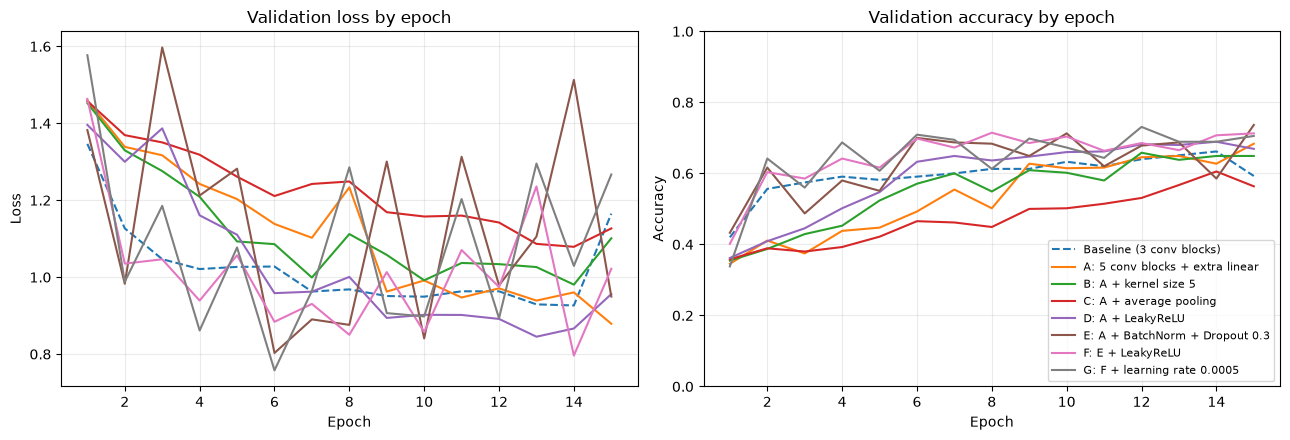

In [14]:
# Validation curves for every experiment (training curves left out to keep the plot readable).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, h in histories.items():
    style = '--' if name.startswith('Baseline') else '-'
    axes[0].plot(epochs, h['val_loss'], style, label=name)
    axes[1].plot(epochs, h['val_accuracy'], style, label=name)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Validation loss by epoch')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Validation accuracy by epoch', ylim=(0, 1))
for ax in axes:
    ax.grid(alpha=0.25)
axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### 11.3 Results and observations

Results at each model's selected epoch (lowest validation loss). **Gap** = training accuracy − validation accuracy; a large gap means the model fits the training images much better than new ones (overfitting).

| Experiment | Params | Selected epoch | Val loss | Val acc | Train acc | Gap |
|---|---|---|---|---|---|---|
| Baseline (3 conv blocks) | 286,117 | 14 | 0.926 | 66.2% | 73.2% | 7.0% |
| A: 5 conv blocks + extra linear | 532,389 | 15 | 0.879 | 68.4% | 72.9% | 4.6% |
| B: A + kernel size 5 | 1,229,477 | 14 | 0.981 | 64.9% | 75.1% | 10.2% |
| C: A + average pooling | 532,389 | 14 | 1.079 | 60.5% | 58.7% | −1.8% |
| D: A + LeakyReLU | 532,389 | 13 | 0.845 | 68.0% | 73.2% | 5.2% |
| E: A + BatchNorm + Dropout 0.3 | 533,381 | 6 | 0.803 | 70.0% | 72.2% | 2.2% |
| F: E + LeakyReLU | 533,381 | 14 | 0.796 | 70.7% | 87.5% | 16.8% |
| **G: F + learning rate 0.0005** | 533,381 | 6 | **0.758** | **70.9%** | 76.4% | 5.5% |

**Observations:**
- **A (deeper network, required change):** the 2 extra conv blocks and the extra linear layer improved validation loss (0.926 → 0.879) and accuracy (66.2% → 68.4%) with a *smaller* train/val gap. It learns more slowly at first, and its best epoch was the last one, so it had not finished improving within 15 epochs.
- **B (5×5 kernels):** worse than A. It has 2.3× as many parameters and the largest gap among the non-BatchNorm runs (10.2%), so the extra capacity went into memorizing training images. 3×3 kernels work better for 64×64 images.
- **C (average pooling):** the worst run. Its training accuracy is *below* its validation accuracy, which points to underfitting rather than overfitting. Averaging blurs the strongest edge and texture responses that max pooling keeps.
- **D (LeakyReLU):** a small gain over A (val loss 0.879 → 0.845). LeakyReLU passes a small gradient for negative inputs, so fewer units stop learning.
- **E (BatchNorm + Dropout):** the biggest single improvement (val loss 0.803, 70.0% val accuracy), reached by epoch 6. BatchNorm makes training much faster: training accuracy after epoch 1 is about 51% versus 31% for A. The validation loss is noisy from epoch to epoch, though, and training accuracy keeps climbing toward 90% by epoch 15 while validation loss does not improve. That is overfitting in the later epochs. Selecting the best validation epoch (6) avoids it.
- **F (E + LeakyReLU):** a slightly lower validation loss than E, but at its selected epoch training accuracy is 87.5% against 70.7% validation (a 16.8% gap). That model is clearly overfitting, so it is not a good choice even though its validation loss looks fine.
- **G (lower learning rate):** halving the learning rate gave the best validation loss (0.758) and accuracy (70.9%), with a moderate 5.5% gap at the selected epoch. **G is selected.**

**Overfitting checks:** decisions use the validation set only, each run keeps the epoch with the lowest validation loss, and the test set is used once, below. The plot above shows that for the BatchNorm models (E, F, G) validation loss bottoms out early and then gets noisier and higher, so training longer than 15 epochs would only make overfitting worse.

### 11.4 Evaluate the selected model on the test set (once)

The experiment with the lowest validation loss is selected automatically. Only now is the test set used, with the same metrics as Section 8.

Selected by validation loss: G: F + learning rate 0.0005


Test accuracy:     71.69%  (baseline 66.42%)
Balanced accuracy: 71.45%  (baseline 65.13%)
              precision    recall  f1-score   support

       daisy       0.69      0.71      0.70        95
   dandelion       0.69      0.82      0.75       135
       roses       0.65      0.64      0.64        96
  sunflowers       0.75      0.88      0.81       105
      tulips       0.83      0.53      0.65       120

    accuracy                           0.72       551
   macro avg       0.72      0.71      0.71       551
weighted avg       0.73      0.72      0.71       551



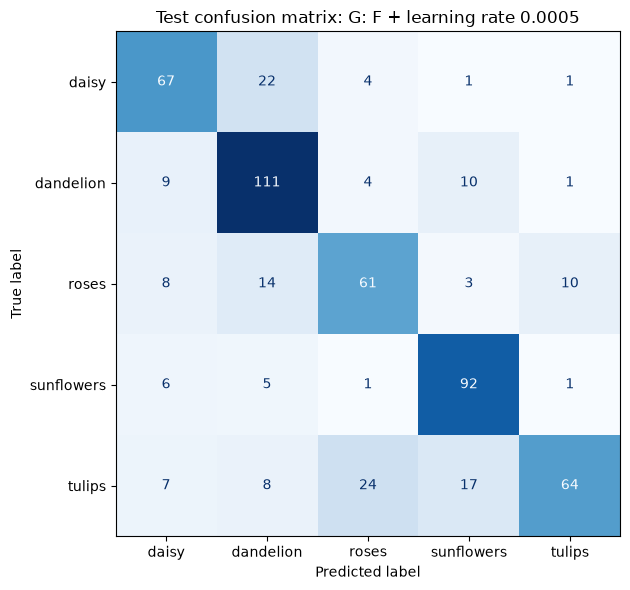

In [15]:
best_name = min(trained_models, key=lambda name: results[name]['val_loss'])
model = trained_models[best_name]
print('Selected by validation loss:', best_name)

model.eval()
true_labels, predicted_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        predicted_labels.extend(model(inputs.to(device)).argmax(1).cpu().numpy())
        true_labels.extend(labels.numpy())
true_labels, predicted_labels = np.asarray(true_labels), np.asarray(predicted_labels)
test_accuracy = accuracy_score(true_labels, predicted_labels)
balanced_accuracy = balanced_accuracy_score(true_labels, predicted_labels)
print(f'Test accuracy:     {test_accuracy:.2%}  (baseline {baseline_test_accuracy:.2%})')
print(f'Balanced accuracy: {balanced_accuracy:.2%}  (baseline {baseline_balanced_accuracy:.2%})')
print(classification_report(true_labels, predicted_labels,
      labels=list(range(len(class_names))), target_names=class_names, zero_division=0))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(true_labels, predicted_labels,
    labels=list(range(len(class_names))), display_labels=class_names,
    cmap='Blues', colorbar=False, ax=ax)
ax.set_title(f'Test confusion matrix: {best_name}')
plt.tight_layout()
plt.show()

### 11.5 Conclusion

**Final model (G):** 5 conv blocks (16 → 32 → 64 → 128 → 256 filters, 3×3 kernels, BatchNorm, LeakyReLU, max pooling), then a classifier of 1024 → 128 → 64 → 5 with Dropout 0.3. It is trained with Adam at learning rate 0.0005 for 15 epochs, keeping the weights from the lowest-validation-loss epoch (6).

| | Baseline (Sections 5–8) | Final model (G) |
|---|---|---|
| Test accuracy | 66.42% | **71.69%** (+5.3 points) |
| Balanced accuracy | 65.13% | **71.45%** (+6.3 points) |
| Roses recall | 0.35 | 0.64 |
| Tulips recall | 0.68 | 0.53 |

- The "75%" quoted for the baseline is its **training** accuracy at the last epoch. On held-out data, the baseline scores 66.4% on the test set, and that is the fair number to compare against.
- **What helped:** adding depth (A), and above all BatchNorm + Dropout (E) and a lower learning rate (G). LeakyReLU gave a small extra gain. **What hurt:** 5×5 kernels (B) and average pooling (C).
- The largest per-class gain was on roses, which the baseline missed most often (recall 0.35 → 0.64). Tulips got worse (0.68 → 0.53), so roses and tulips are still the hardest pair to tell apart.
- Even the best model starts overfitting after about 6 epochs: training accuracy keeps rising while validation loss does not. With only ~2,500 training images and no augmentation, the model runs out of new information to learn. Data augmentation, which was out of scope here, would be the natural next step.